# M-ABSA EDA & Feature Engineering Pipeline
## Ngôn ngữ: **DE** (Tiếng Đức / German) | Domains: `Restaurant` & `Phone`

---

| Phase | Nội dung | Tập dữ liệu |
|-------|----------|-----------|
| 1 | Data Ingestion & Triplet Parsing | Raw → JSONL |
| 2 | Macro EDA & Physical Constraints | **Train only** |
| 3 | Micro-Linguistic & Translationese Artifacts | **Train only** |
| 4 | Cross-Split Covariate Shift & Integrity | Train / Val / Test |
| 5 | Model Configuration Summary | — |

> **Data Leakage Rule**: mọi thống kê siêu tham số (`max_length`, `class_weight`, `dropout`) **chỉ tính trên tập Train**. Val/Test chỉ được mở ở Phase 4.
>
> **Lưu ý**: tiếng Đức có hiện tượng từ ghép dài, biến tố, viết hoa danh từ và phủ định bằng `nicht/kein`; notebook vẫn dùng tokenizer XLM-R để đo độ dài đầu vào model, đồng thời dùng heuristic từ/ngữ đoạn cho phân tích vi mô.


## Global Config

In [1]:
TARGET_LANG    = "de"
TOKENIZER_NAME = "xlm-roberta-base"
DOMAINS        = ["restaurant", "phone"]
SPLITS         = ["training", "dev", "test"]
SPLIT_ALIAS    = {"training": "train", "dev": "val", "test": "test"}

NEUTRAL_SAFE_THRESHOLD  = 10.0
RARE_CATEGORY_THRESHOLD = 20
ARTIFACT_HIGH_THRESHOLD = 0.25

DROPOUT_MAP = [
    (0.35, 0.20),
    (0.25, 0.15),
    (0.00, 0.10),
]

print(f"Target language : {TARGET_LANG}")
print(f"Tokenizer       : {TOKENIZER_NAME}")
print(f"Domains         : {DOMAINS}")

Target language : de
Tokenizer       : xlm-roberta-base
Domains         : ['restaurant', 'phone']


In [2]:
from __future__ import annotations
import ast, json, re, unicodedata, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 80)

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["font.family"]       = "DejaVu Sans"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_theme(style="whitegrid", context="notebook")

C = {
    "positive": "#27ae60", "negative": "#e74c3c", "neutral": "#3498db",
    "artifact": "#e67e22", "train":    "#2c3e50",
    "val":      "#8e44ad", "test":     "#e74c3c",
}
print("Imports OK")

Imports OK


---
# PHASE 1 — DATA INGESTION & TRIPLET PARSING

Load raw `.txt`, lọc DE, parse `text####[[term,cat,sent],...]` → JSONL.

```
Raw .txt  →  parse_raw_line()  →  records[]  →  JSONL
```

> Notebook này dùng `train.txt/dev.txt/test.txt` cho DE nhưng vẫn chuẩn hóa tên split nội bộ thành `training/dev/test` để khớp pipeline của `EDA_VI`.


### 1.1 — Setup data root

In [3]:
import zipfile, os

colab_zip = Path("/content/data.zip")
if colab_zip.exists():
    with zipfile.ZipFile(colab_zip, "r") as zf:
        zf.extractall("/content/")
    print("Extracted /content/data.zip")


def _looks_like_raw_root(p: Path) -> bool:
    """A raw root is expected to contain {restaurant,phone}/{lang}/{train,dev,test}.txt."""
    if not p.exists():
        return False
    langs_to_probe = [TARGET_LANG, "en", "vi", "de"]
    for domain in DOMAINS:
        for lang in langs_to_probe:
            for fname in ["train.txt", "training.txt", "dev.txt", "test.txt"]:
                if (p / domain / lang / fname).exists():
                    return True
    return False


def find_data_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "raw",
        cwd / "data",
        cwd.parent / "data" / "raw",
        cwd.parent / "data",
        cwd.parent.parent / "data" / "raw",
        cwd.parent.parent / "data",
        Path("/content/data/raw"), Path("/content/data"),
        Path("/mnt/data/data/raw"), Path("/mnt/data/data"),
        Path(r"C:/Project_NLP_23KDL/data/raw"),
        Path(r"C:/Project_NLP_23KDL/data"),
    ]
    for p in candidates:
        if _looks_like_raw_root(p):
            return p
    raise FileNotFoundError(
        "Không tìm thấy thư mục raw data. Chạy cell 1.2 để tải từ HuggingFace "
        "hoặc đặt data theo dạng data/raw/{restaurant,phone}/{de,en,vi,...}/{train,dev,test}.txt."
    )


def make_processed_dir(data_root: Path) -> Path:
    # Nếu root là data/raw -> lưu tại data/processed/de.
    # Nếu root là data trực tiếp chứa restaurant/phone -> lưu tại data/processed/de.
    if data_root.name.lower() == "raw":
        return data_root.parent / "processed" / TARGET_LANG
    return data_root / "processed" / TARGET_LANG

try:
    DATA_ROOT     = find_data_root()
    PROCESSED_DIR = make_processed_dir(DATA_ROOT)
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Data root    : {DATA_ROOT}")
    print(f"Processed dir: {PROCESSED_DIR}")
except FileNotFoundError as e:
    print(f"[WARN] {e}")
    DATA_ROOT = None

Data root    : D:\Project_NLP\Cross-lingual-ABSA-EN-VI-Transfer 2\Cross-lingual-ABSA-EN-VI-Transfer\data\raw
Processed dir: D:\Project_NLP\Cross-lingual-ABSA-EN-VI-Transfer 2\Cross-lingual-ABSA-EN-VI-Transfer\data\processed\de


### 1.2 — Download from HuggingFace (nếu chưa có trong local)

In [4]:
if DATA_ROOT is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import snapshot_download
    print("Đang tải M-ABSA từ HuggingFace...")
    snapshot_download(
        repo_id="Multilingual-NLP/M-ABSA", repo_type="dataset",
        local_dir="./data/raw",
        ignore_patterns=["*.md", "*.gitattributes"],
    )
    DATA_ROOT     = Path("./data/raw")
    PROCESSED_DIR = Path("./data/processed") / TARGET_LANG
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Download xong -> {DATA_ROOT.resolve()}")
else:
    print("Dùng data local — bỏ qua download.")

Dùng data local — bỏ qua download.


### 1.3 — Parser functions

In [5]:
SENTIMENT_ALIASES = {"pos": "positive", "neg": "negative", "neu": "neutral"}
VALID_SENTIMENTS  = {"positive", "negative", "neutral"}

TRIPLET_RE = re.compile(
    r"\[\s*(?P<q>['\"])(?P<term>.*?)(?P=q)\s*,"
    r"\s*['\"](?P<cat>.*?)['\"]\s*,"
    r"\s*['\"](?P<sent>positive|negative|neutral)['\"]\s*\]",
    re.IGNORECASE,
)


def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", str(text)).strip())


def normalize_category(cat: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", str(cat)).strip().lower())


def normalize_sentiment(sent: str) -> str:
    raw = str(sent).strip().lower()
    return SENTIMENT_ALIASES.get(raw, raw)


def parse_triplet_blob(blob: str):
    """Return (triplets_list, method). method: ast / regex / empty / fail."""
    blob = blob.strip()
    if blob in ("", "[]"):
        return [], "empty"
    try:
        raw = ast.literal_eval(blob)
        out = []
        for t in raw:
            if len(t) >= 3:
                out.append((
                    "NULL" if t[0] is None else str(t[0]),
                    str(t[1]),
                    normalize_sentiment(str(t[2])),
                ))
        return out, "ast"
    except Exception:
        pass
    matches = list(TRIPLET_RE.finditer(blob))
    if matches:
        return [
            (m.group("term") or "NULL", m.group("cat"), normalize_sentiment(m.group("sent")))
            for m in matches
        ], "regex"
    return [], "fail"


def parse_raw_line(line: str):
    """Return (text, triplets, method) or (None, None, error_str)."""
    line = line.strip()
    if not line or "####" not in line:
        return None, None, "missing_separator"
    text_raw, blob = line.split("####", 1)
    text = normalize_text(text_raw)
    if not text:
        return None, None, "empty_text"
    triplets, method = parse_triplet_blob(blob)
    if method == "fail":
        return None, None, "parse_fail"
    return text, triplets, method


print("Parser functions defined.")

Parser functions defined.


### 1.4 — Ingest all DE data

In [6]:
SPLIT_FILENAMES = {"training": "train.txt", "dev": "dev.txt", "test": "test.txt"}
records   = []
parse_log = []

if DATA_ROOT is None:
    raise FileNotFoundError("DATA_ROOT is None. Hãy chạy cell 1.2 hoặc kiểm tra đường dẫn dữ liệu.")

for domain in DOMAINS:
    for split in SPLITS:
        fpath = DATA_ROOT / domain / TARGET_LANG / SPLIT_FILENAMES[split]
        if not fpath.exists():
            print(f"[SKIP] not found: {fpath}")
            continue
        n_sent = n_triplets = n_ast = n_regex = n_empty = n_fail = 0
        with open(fpath, encoding="utf-8") as f:
            for line_no, line in enumerate(f, 1):
                text, triplets, method = parse_raw_line(line)
                if text is None:
                    n_fail += 1
                    continue
                n_sent += 1
                if   method == "ast":   n_ast   += 1
                elif method == "regex": n_regex += 1
                elif method == "empty": n_empty += 1
                for trip_idx, (term, cat, sent) in enumerate(triplets):
                    term = "NULL" if term is None or str(term).strip() == "" else str(term).strip()
                    records.append({
                        "sentence_id"    : f"{domain}_{TARGET_LANG}_{split}_{line_no:05d}",
                        "domain"         : domain,
                        "lang"           : TARGET_LANG,
                        "split"          : split,
                        "text"           : text,
                        "aspect_term"    : term,
                        "is_implicit"    : (term.upper() == "NULL"),
                        "raw_category"   : cat,
                        "aspect_category": normalize_category(cat),
                        "sentiment"      : sent,
                        "is_valid_sent"  : sent in VALID_SENTIMENTS,
                        "trip_idx"       : trip_idx,
                    })
                    n_triplets += 1
        parse_log.append({"domain":domain,"split":split,"n_sentences":n_sent,
                          "n_triplets":n_triplets,"ast":n_ast,"regex":n_regex,
                          "empty":n_empty,"fail":n_fail})
        print(f"[{domain:10s}|{split:8s}] {n_sent:4d} câu | {n_triplets:5d} triplets "
              f"| ast={n_ast} regex={n_regex} empty={n_empty} fail={n_fail}")

df       = pd.DataFrame(records)
parse_df = pd.DataFrame(parse_log)
print(f"\nTổng bản ghi: {len(df):,}")

if len(df) == 0:
    print("[WARN] Không ingest được bản ghi DE nào. Kiểm tra DATA_ROOT và sự tồn tại của thư mục de.")

[restaurant|training] 1264 câu |  1989 triplets | ast=1256 regex=8 empty=0 fail=0
[restaurant|dev     ]  316 câu |   507 triplets | ast=313 regex=3 empty=0 fail=0
[restaurant|test    ]  544 câu |   799 triplets | ast=538 regex=6 empty=0 fail=0
[phone     |training] 1276 câu |  2883 triplets | ast=1073 regex=0 empty=203 fail=0
[phone     |dev     ]  307 câu |   710 triplets | ast=256 regex=0 empty=51 fail=0
[phone     |test    ]  522 câu |  1217 triplets | ast=449 regex=0 empty=73 fail=0

Tổng bản ghi: 8,105


### 1.5 — Export JSONL

In [7]:
for domain in DOMAINS:
    for split in SPLITS:
        subset   = df[(df["domain"]==domain) & (df["split"]==split)]
        alias    = SPLIT_ALIAS[split]
        out_path = PROCESSED_DIR / f"{domain}_{TARGET_LANG}_{alias}.jsonl"
        with open(out_path,"w",encoding="utf-8") as f:
            for _, row in subset.iterrows():
                f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")
        print(f"Saved {len(subset):5d} rows -> {out_path.name}")
print("\nJSONL export done.")

Saved  1989 rows -> restaurant_de_train.jsonl
Saved   507 rows -> restaurant_de_val.jsonl
Saved   799 rows -> restaurant_de_test.jsonl
Saved  2883 rows -> phone_de_train.jsonl
Saved   710 rows -> phone_de_val.jsonl
Saved  1217 rows -> phone_de_test.jsonl

JSONL export done.


### 1.6 — Parse Quality Report

In [8]:
if parse_df.empty:
    raise FileNotFoundError(
        f"Không tìm thấy file raw cho ngôn ngữ {TARGET_LANG.upper()} dưới DATA_ROOT={DATA_ROOT}. "
        "Cần có data/raw/{restaurant,phone}/de/{train,dev,test}.txt."
    )

display(parse_df.set_index(["domain","split"]))
assert int(parse_df["fail"].sum()) == 0, f"{parse_df['fail'].sum()} parse failures!"
print("Zero parse failures.")

n_sentences  n_triplets   ast  regex  empty  fail
domain     split                                                      
restaurant training         1264        1989  1256      8      0     0
           dev               316         507   313      3      0     0
           test              544         799   538      6      0     0
phone      training         1276        2883  1073      0    203     0
           dev               307         710   256      0     51     0
           test              522        1217   449      0     73     0

Zero parse failures.


---
# PHASE 2 — MACRO EDA & PHYSICAL CONSTRAINTS (Train only)

> **Chỉ dùng tập Train** để thiết lập siêu tham số, nhằm tránh rò rỉ dữ liệu.

- 2.1 Token Length Distribution → `max_length`
- 2.2 Label Imbalance → `class_weight` / Focal Loss
- 2.3 Category Sparsity & Mapping Matrix

In [9]:
train_df = df[(df["split"]=="training") & (df["is_valid_sent"])].copy()
print(f"Train rows : {len(train_df):,}")
print(f"  restaurant: {len(train_df[train_df.domain=='restaurant']):,}")
print(f"  phone     : {len(train_df[train_df.domain=='phone']):,}")

Train rows : 4,872
  restaurant: 1,989
  phone     : 2,883


### 2.1 — Token Length Distribution (xlm-roberta-base)

In [10]:
try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    print(f"Tokenizer loaded: {TOKENIZER_NAME}")
except Exception as e:
    print(f"[ERR] {e}\nCài: pip install transformers sentencepiece")
    raise

Tokenizer loaded: xlm-roberta-base


In [11]:
def batched_token_lengths(texts, text_pairs=None, batch_size=512):
    lengths = []
    for start in range(0, len(texts), batch_size):
        bt = texts[start:start+batch_size]
        if text_pairs is None:
            enc = tokenizer(bt, truncation=False, padding=False)
        else:
            bp  = text_pairs[start:start+batch_size]
            enc = tokenizer(bt, bp, truncation=False, padding=False)
        lengths.extend(len(ids) for ids in enc["input_ids"])
    return lengths

texts = train_df["text"].tolist()
cats  = train_df["raw_category"].tolist()
train_df["text_token_len"] = batched_token_lengths(texts)
train_df["pair_token_len"] = batched_token_lengths(texts, cats)
print("Token lengths computed. Sample:")
display(train_df[["domain","aspect_category","text_token_len","pair_token_len"]].head(3))

Token lengths computed. Sample:


,domain,aspect_category,text_token_len,pair_token_len
0,restaurant,service general,25,29
1,restaurant,food quality,25,29
2,restaurant,ambience general,19,25


In [12]:
def pct_higher(values, q):
    arr = np.asarray(values, dtype=float)
    try:    return int(np.percentile(arr, q, method="higher"))
    except: return int(np.percentile(arr, q, interpolation="higher"))


def length_summary(sub_df, group_cols, len_col="pair_token_len"):
    rows = []
    for keys, g in sub_df.groupby(group_cols):
        if not isinstance(keys, tuple): keys = (keys,)
        vals = g[len_col].to_numpy()
        row  = dict(zip(group_cols, keys))
        row.update({"n":len(g),"mean":round(float(np.mean(vals)),1),
                    "max":int(np.max(vals)),
                    "p90":pct_higher(vals,90),
                    "p95":pct_higher(vals,95),
                    "p99":pct_higher(vals,99)})
        rows.append(row)
    return pd.DataFrame(rows)


len_by_domain = length_summary(train_df, ["domain"])
train_df["char_len"] = train_df["text"].astype(str).str.len()
char_by_domain = length_summary(train_df, ["domain"], len_col="char_len")
print("=== Token Length Summary (Train DE -- pair: text + category) ===")
display(len_by_domain)
print("=== Character Length Summary (Train DE -- raw text) ===")
display(char_by_domain)

=== Token Length Summary (Train DE -- pair: text + category) ===


,domain,n,mean,max,p90,p95,p99
0,phone,2883,61.9,265,115,168,226
1,restaurant,1989,28.7,104,48,57,72


=== Character Length Summary (Train DE -- raw text) ===


,domain,n,mean,max,p90,p95,p99
0,phone,2883,224.1,1052,460,693,904
1,restaurant,1989,91.7,423,169,199,289


In [13]:
# ─── Phase 2.1 — SELF-CONTAINED (không phụ thuộc cell trước) ────
import numpy as np
import pandas as pd

# ── 1. Lấy tokenizer (tái dùng nếu đã có, tự tạo nếu chưa) ──────
try:
    tokenizer   # dùng lại nếu đã load
except NameError:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    print("Tokenizer loaded.")

# ── 2. Đảm bảo pair_token_len có trong train_df ──────────────────
if "pair_token_len" not in train_df.columns:
    print("Đang tính token lengths...")
    def _batch_len(texts, pairs=None, bs=512):
        out = []
        for i in range(0, len(texts), bs):
            bt = texts[i:i+bs]
            enc = tokenizer(bt, pairs[i:i+bs] if pairs else None,
                            truncation=False, padding=False)
            out.extend(len(x) for x in enc["input_ids"])
        return out
    train_df["text_token_len"] = _batch_len(train_df["text"].tolist())
    train_df["pair_token_len"] = _batch_len(
        train_df["text"].tolist(),
        train_df["raw_category"].tolist(),
    )
    print("Done.")

# ── 3. Rebuild len_by_domain từ đầu (bỏ qua biến cũ) ────────────
def _pct(values, q):
    arr = np.asarray(values, dtype=float)
    try:    return int(np.percentile(arr, q, method="higher"))
    except: return int(np.percentile(arr, q, interpolation="higher"))

rows = []
for domain, g in train_df.groupby("domain"):
    vals = g["pair_token_len"].to_numpy()
    rows.append({
        "domain": domain,
        "n"     : len(g),
        "mean"  : round(float(np.mean(vals)), 1),
        "max"   : int(np.max(vals)),
        "p90"   : _pct(vals, 90),
        "p95"   : _pct(vals, 95),
        "p99"   : _pct(vals, 99),
    })
len_by_domain = pd.DataFrame(rows)          # ghi đè bất kỳ biến cũ nào

print("=== Token Length Summary (Train DE — pair: text + category) ===")
display(len_by_domain)

# ── 4. Suggest max_length ─────────────────────────────────────────
p95_max = int(len_by_domain["p95"].max())
p99_max = int(len_by_domain["p99"].max())
_cands  = [64, 96, 128, 160, 192, 256, 320, 384, 512]

max_len_rec = pd.DataFrame([
    {"policy": "p95_safe",
     "max_length": next(x for x in _cands if x >= p95_max),
     "reason": f"Che phủ p95={p95_max}"},
    {"policy": "p99_safe",
     "max_length": next(x for x in _cands if x >= p99_max),
     "reason": f"Che phủ p99={p99_max}"},
])

RECOMMENDED_MAX_LENGTH = int(
    max_len_rec.loc[max_len_rec["policy"] == "p95_safe", "max_length"].iloc[0]
)

print("\nKhuyến nghị max_length:")
display(max_len_rec)
print(f"\n→ Chọn (p95_safe): max_length = {RECOMMENDED_MAX_LENGTH}")

=== Token Length Summary (Train DE — pair: text + category) ===


,domain,n,mean,max,p90,p95,p99
0,phone,2883,61.9,265,115,168,226
1,restaurant,1989,28.7,104,48,57,72



Khuyến nghị max_length:


,policy,max_length,reason
0,p95_safe,192,Che phủ p95=168
1,p99_safe,256,Che phủ p99=226



→ Chọn (p95_safe): max_length = 192


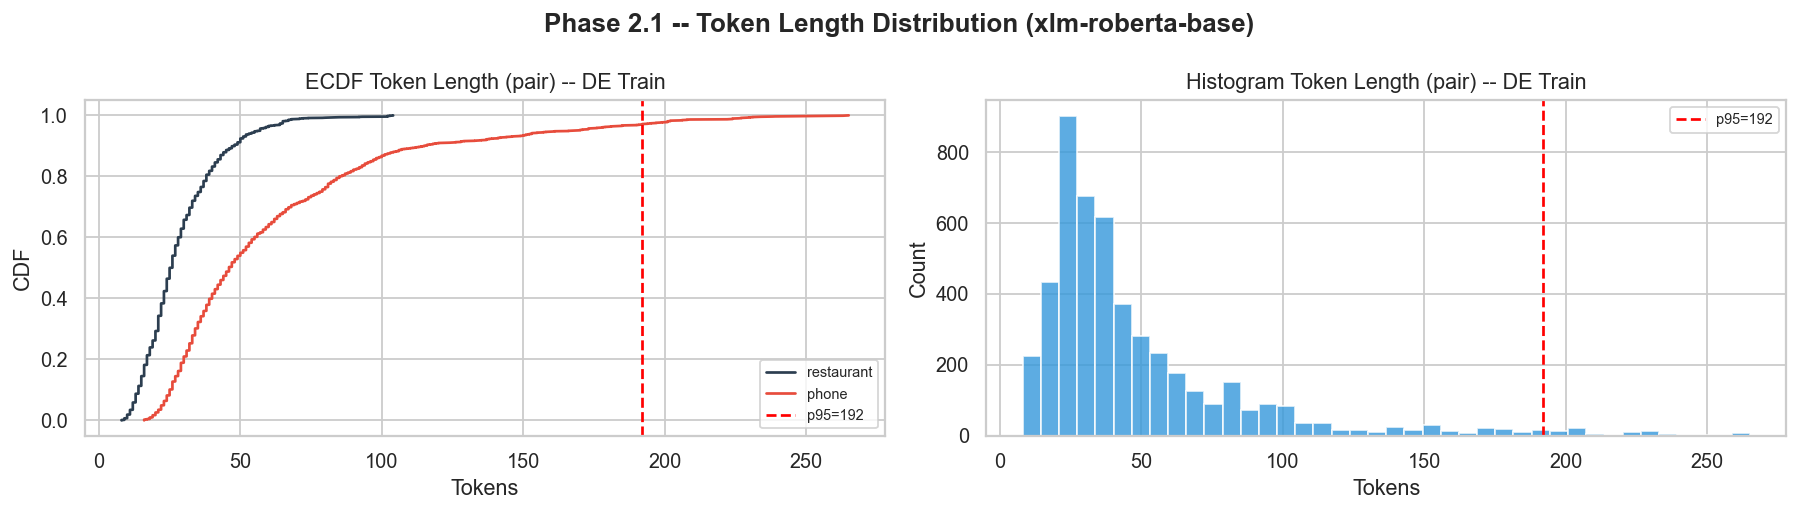

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for dom, color in zip(DOMAINS, ["#2c3e50","#e74c3c"]):
    vals = np.sort(train_df[train_df["domain"]==dom]["pair_token_len"])
    ax.plot(vals, np.arange(1,len(vals)+1)/len(vals), label=dom, color=color)
ax.axvline(RECOMMENDED_MAX_LENGTH, color="red", ls="--", lw=1.5,
           label=f"p95={RECOMMENDED_MAX_LENGTH}")
ax.set(title="ECDF Token Length (pair) -- DE Train", xlabel="Tokens", ylabel="CDF")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(train_df["pair_token_len"], bins=40, color="#3498db", alpha=0.8)
ax.axvline(RECOMMENDED_MAX_LENGTH, color="red", ls="--", lw=1.5,
           label=f"p95={RECOMMENDED_MAX_LENGTH}")
ax.set(title="Histogram Token Length (pair) -- DE Train", xlabel="Tokens", ylabel="Count")
ax.legend(fontsize=8)

plt.suptitle("Phase 2.1 -- Token Length Distribution (xlm-roberta-base)",
             fontweight="bold")
plt.tight_layout()
plt.show()

### 2.2 — Label Imbalance Assessment

In [15]:
def label_distribution(sub_df, group_cols):
    counts = (sub_df.groupby(group_cols+["sentiment"])
              .size().rename("count").reset_index())
    pivot = counts.pivot_table(index=group_cols, columns="sentiment",
                               values="count", fill_value=0).reset_index()
    for lbl in ["positive","negative","neutral"]:
        if lbl not in pivot.columns: pivot[lbl] = 0
    pivot["total"] = pivot[["positive","negative","neutral"]].sum(axis=1)
    for lbl in ["positive","negative","neutral"]:
        pivot[f"{lbl}_pct"] = (pivot[lbl]/pivot["total"]*100).round(2)
    pivot["needs_class_weight"] = pivot["neutral_pct"] < NEUTRAL_SAFE_THRESHOLD
    return pivot


label_by_domain = label_distribution(train_df, ["domain"])
print("=== Label Distribution -- DE Train ===")
display(label_by_domain[["domain","positive","negative","neutral","total",
                          "positive_pct","negative_pct","neutral_pct","needs_class_weight"]])

=== Label Distribution -- DE Train ===


sentiment,domain,positive,negative,neutral,total,positive_pct,negative_pct,neutral_pct,needs_class_weight
0,phone,2120.0,647.0,116.0,2883.0,73.53,22.44,4.02,True
1,restaurant,1369.0,558.0,62.0,1989.0,68.83,28.05,3.12,True


In [16]:
def class_weight_table(dist_df, group_cols):
    rows = []
    for _, row in dist_df.iterrows():
        total = row["total"]
        item  = {col: row[col] for col in group_cols}
        for lbl in ["positive","negative","neutral"]:
            cnt = row[lbl]
            item[f"w_{lbl}"] = round(total/(3*cnt),4) if cnt>0 else float("nan")
        rows.append(item)
    return pd.DataFrame(rows)


cw = class_weight_table(label_by_domain, ["domain"])
print("Class Weights (total / (3 x class_count)):")
display(cw)

REQUIRES_CLASS_WEIGHT = bool(label_by_domain["needs_class_weight"].any())
print(f"requires_class_weight = {REQUIRES_CLASS_WEIGHT}")

Class Weights (total / (3 x class_count)):


,domain,w_positive,w_negative,w_neutral
0,phone,0.4533,1.4853,8.2845
1,restaurant,0.4843,1.1882,10.6935


requires_class_weight = True


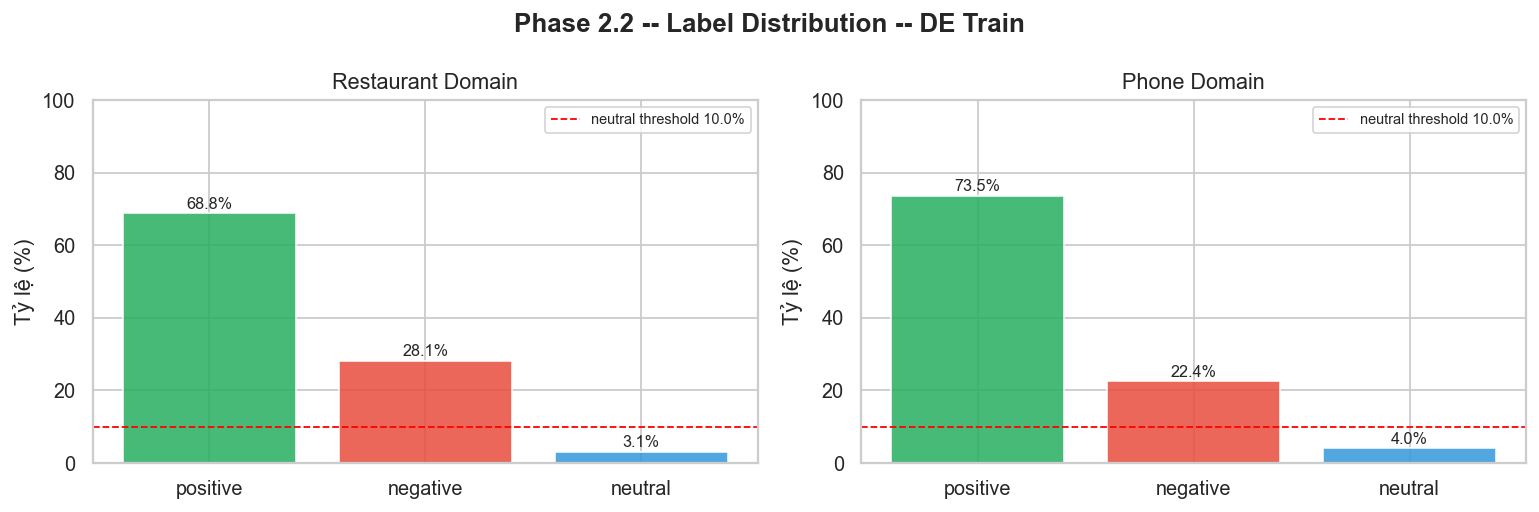

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lbls   = ["positive","negative","neutral"]
colors = [C[l] for l in lbls]

for ax, dom in zip(axes, DOMAINS):
    row  = label_by_domain[label_by_domain["domain"]==dom].iloc[0]
    pcts = [row[f"{l}_pct"] for l in lbls]
    bars = ax.bar(lbls, pcts, color=colors, alpha=0.85, edgecolor="white")
    ax.axhline(NEUTRAL_SAFE_THRESHOLD, color="red", ls="--", lw=1,
               label=f"neutral threshold {NEUTRAL_SAFE_THRESHOLD}%")
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{dom.capitalize()} Domain", ylabel="Tỷ lệ (%)", ylim=(0,100))
    ax.legend(fontsize=8)

plt.suptitle("Phase 2.2 -- Label Distribution -- DE Train", fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 — Category Sparsity & Mapping Matrix

In [18]:
def category_sparsity(sub_df, domain):
    dom_df = sub_df[sub_df["domain"]==domain]
    counts = (
        dom_df.groupby("aspect_category")
        .agg(n_samples=("sentence_id","count"),
             pos=("sentiment",lambda x:(x=="positive").sum()),
             neg=("sentiment",lambda x:(x=="negative").sum()),
             neu=("sentiment",lambda x:(x=="neutral").sum()))
        .reset_index().sort_values("n_samples",ascending=False)
    )
    counts["is_rare"]     = counts["n_samples"] < RARE_CATEGORY_THRESHOLD
    counts["category_id"] = range(len(counts))
    return counts


cat_rest  = category_sparsity(train_df, "restaurant")
cat_phone = category_sparsity(train_df, "phone")

print(f"Restaurant: {len(cat_rest):3d} categories "
      f"({cat_rest['is_rare'].sum()} rare < {RARE_CATEGORY_THRESHOLD})")
print(f"Phone     : {len(cat_phone):3d} categories "
      f"({cat_phone['is_rare'].sum()} rare < {RARE_CATEGORY_THRESHOLD})")
print("\n--- Restaurant (top 10) ---")
display(cat_rest.head(10))
print("\n--- Phone (top 10) ---")
display(cat_phone.head(10))

Restaurant:  12 categories (1 rare < 20)
Phone     :  84 categories (43 rare < 20)

--- Restaurant (top 10) ---


,aspect_category,n_samples,pos,neg,neu,is_rare,category_id
5,food quality,693,495,174,24,False,0
11,service general,356,196,157,3,False,1
8,restaurant general,308,240,62,6,False,2
0,ambience general,222,171,43,8,False,3
6,food style_options,97,62,29,6,False,4
9,restaurant miscellaneous,81,52,23,6,False,5
4,food prices,62,31,29,2,False,6
10,restaurant prices,61,27,30,4,False,7
2,drinks quality,40,37,3,0,False,8
3,drinks style_options,30,27,3,0,False,9



--- Phone (top 10) ---


,aspect_category,n_samples,pos,neg,neu,is_rare,category_id
36,overall#overall,546,457,88,1,False,0
35,logistics#speed,240,198,27,15,False,1
33,logistics#lost and damaged,153,132,12,9,False,2
20,buyer attitude#recommendable,124,82,42,0,False,3
40,price#price,92,79,12,1,False,4
26,camera#general,84,52,30,2,False,5
64,seller service#attitude,77,66,11,0,False,6
57,product quality#general,76,62,13,1,False,7
12,battery/longevity#battery life,65,54,11,0,False,8
68,seller service#timeliness of seller service,62,59,3,0,False,9


In [19]:
cat_rest_map  = {r["aspect_category"]:r["category_id"] for _,r in cat_rest.iterrows()}
cat_phone_map = {r["aspect_category"]:r["category_id"] for _,r in cat_phone.iterrows()}
category_maps = {"restaurant":cat_rest_map,"phone":cat_phone_map}

cat_map_path = PROCESSED_DIR / "category_maps.json"
with open(cat_map_path,"w",encoding="utf-8") as f:
    json.dump(category_maps, f, ensure_ascii=False, indent=2)
print(f"Saved category maps -> {cat_map_path}")
print(f"Restaurant: {len(cat_rest_map)} cats | Phone: {len(cat_phone_map)} cats")

Saved category maps -> D:\Project_NLP\Cross-lingual-ABSA-EN-VI-Transfer 2\Cross-lingual-ABSA-EN-VI-Transfer\data\processed\de\category_maps.json
Restaurant: 12 cats | Phone: 84 cats


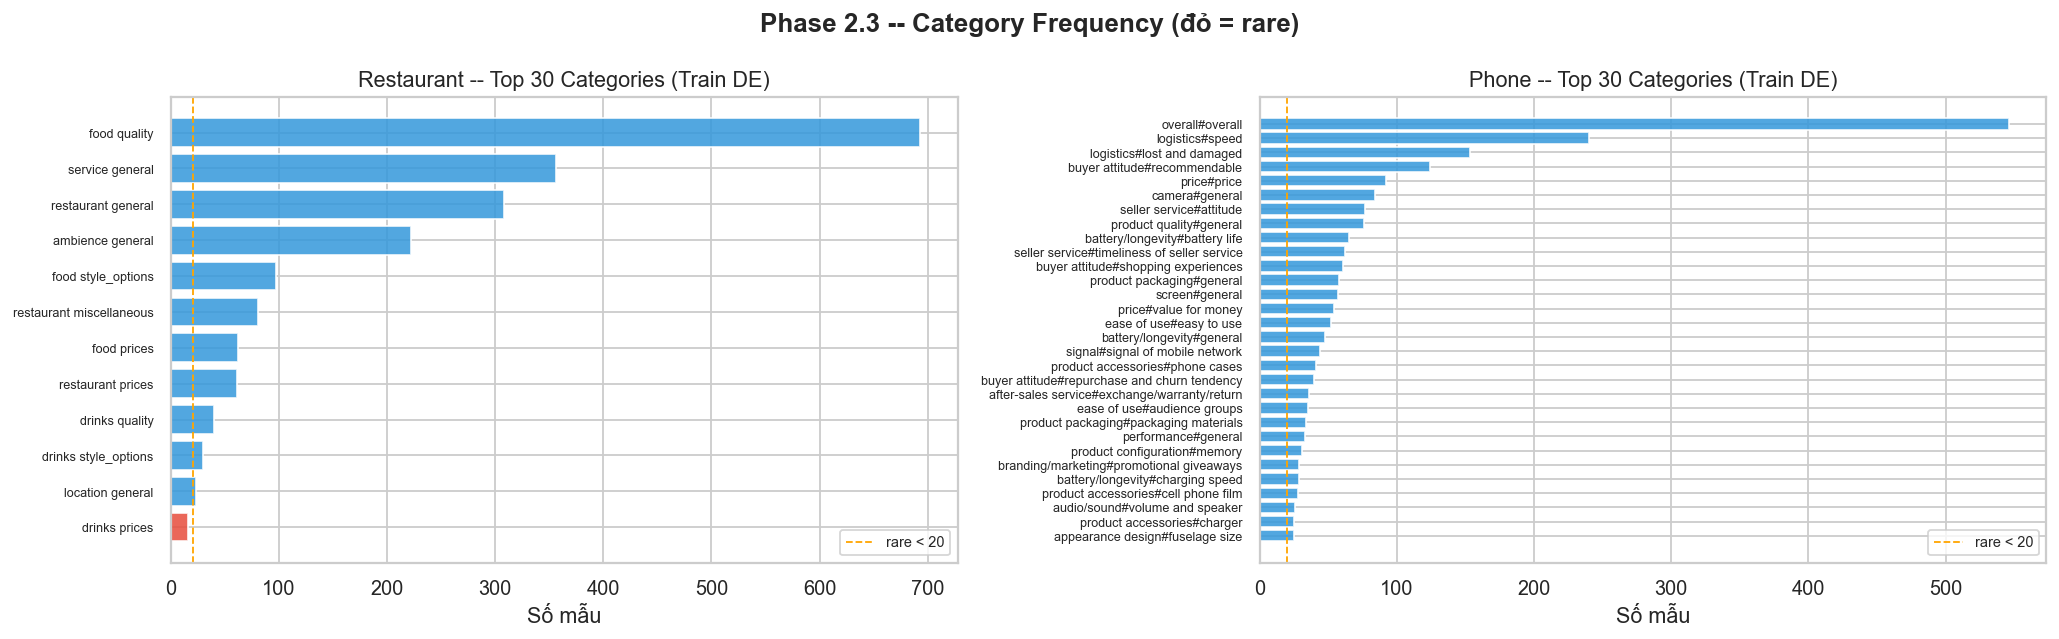

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (cat_df, dom) in zip(axes, [(cat_rest,"restaurant"),(cat_phone,"phone")]):
    top = cat_df.head(30)
    bar_colors = ["#e74c3c" if r else "#3498db" for r in top["is_rare"]]
    ax.barh(top["aspect_category"][::-1], top["n_samples"][::-1],
            color=bar_colors[::-1], alpha=0.85)
    ax.axvline(RARE_CATEGORY_THRESHOLD, color="orange", ls="--", lw=1,
               label=f"rare < {RARE_CATEGORY_THRESHOLD}")
    ax.set(title=f"{dom.capitalize()} -- Top 30 Categories (Train DE)",
           xlabel="Số mẫu")
    ax.legend(fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
plt.suptitle("Phase 2.3 -- Category Frequency (đỏ = rare)", fontweight="bold")
plt.tight_layout()
plt.show()

---
# PHASE 3 — MICRO-LINGUISTIC & TRANSLATIONESE ARTIFACT ANALYSIS (Train only)

Định lượng artifact/translationese trong DE:
- `attention_mask_strategy`: `dynamic` vs `standard`
- `recommended_dropout`: tăng theo artifact rate

**3.1** Phát hiện pronoun/copula/negation/intensifier signals trong NULL aspect samples  
**3.2** Đo tỷ lệ n-gram/từ artifact quanh explicit aspect term

> Các pattern DE dưới đây là heuristic để phát hiện dấu hiệu dịch máy/literal translation, không phải kết luận ngôn ngữ học tuyệt đối. Với tiếng Đức, các tín hiệu đáng chú ý gồm từ ghép dài, phủ định `nicht/kein`, copula `ist/sind`, và cụm dịch máy như `in Bezug auf`, `alles in allem`.


### 3.1 — Implicit NULL Aspect: Pronoun / Copula / Negation Signals


In [21]:
DE_INJECTION_TOKENS = {
    "pronoun"     : ["ich", "wir", "du", "sie", "er", "es", "man", "wir alle"],
    "copula"      : ["ist", "war", "sind", "waren", "sein", "scheint", "wirkt"],
    "existential" : ["es gibt", "gibt", "vorhanden", "keine", "kein"],
    "negation"    : ["nicht", "nie", "niemals", "kein", "keine", "keinen", "keiner", "nichts"],
    "intensifier" : ["sehr", "wirklich", "total", "ziemlich", "besonders", "extrem", "absolut", "echt"],
    "filler"      : ["insgesamt", "alles in allem", "im allgemeinen", "ehrlich gesagt", "tatsächlich", "eigentlich"],
}


def simple_tokenize(text: str):
    """Tokenizer nhẹ cho DE: tách từ tiếng Đức, giữ số và dấu câu."""
    text = unicodedata.normalize("NFC", str(text)).lower().strip()
    return re.findall(r"[a-zäöüß]+(?:[-'][a-zäöüß]+)*|\d+(?:[,.]\d+)?|[^\s]", text)


def _phrase_tokens(phrase: str):
    return simple_tokenize(phrase)


def detect_injection(text: str, inject_dict: dict, window: int = 16):
    """Scan first `window` lightweight tokens for DE injection/signal patterns."""
    tokens = simple_tokenize(text)[:window]
    found_cats, found_toks = [], []
    for cat, inject_list in inject_dict.items():
        for phrase in inject_list:
            pt = _phrase_tokens(phrase)
            if not pt:
                continue
            for i in range(len(tokens)-len(pt)+1):
                if tokens[i:i+len(pt)] == pt:
                    found_cats.append(cat)
                    found_toks.append(phrase)
                    break
    return bool(found_cats), sorted(set(found_cats)), sorted(set(found_toks))


print("DE injection detector defined.")


DE injection detector defined.


In [22]:
implicit_train = train_df[train_df["is_implicit"]].copy()
print(f"Implicit (NULL) samples -- Train DE: {len(implicit_train):,}")
print(f"  Restaurant: {len(implicit_train[implicit_train.domain=='restaurant']):,}")
print(f"  Phone     : {len(implicit_train[implicit_train.domain=='phone']):,}")

if len(implicit_train):
    inj_res = implicit_train["text"].apply(
        lambda t: detect_injection(t, DE_INJECTION_TOKENS)
    )
    implicit_train = implicit_train.copy()
    implicit_train["has_injection"] = [r[0] for r in inj_res]
    implicit_train["inject_cats"]   = [r[1] for r in inj_res]
    implicit_train["inject_tokens"] = [r[2] for r in inj_res]
else:
    implicit_train["has_injection"] = []
    implicit_train["inject_cats"]   = []
    implicit_train["inject_tokens"] = []

n_total  = len(implicit_train)
n_inject = int(implicit_train["has_injection"].sum()) if n_total else 0
inj_rate = n_inject/n_total*100 if n_total > 0 else 0.0

print(f"\nInjection rate (NULL): {n_inject}/{n_total} = {inj_rate:.1f}%")

Implicit (NULL) samples -- Train DE: 449
  Restaurant: 449
  Phone     : 0

Injection rate (NULL): 368/449 = 82.0%


In [23]:
all_cats = [c for cats in implicit_train.get("inject_cats", []) for c in cats]
inj_breakdown = pd.DataFrame(
    Counter(all_cats).most_common(), columns=["injection_type","count"]
)
print("Injection breakdown:")
display(inj_breakdown)

print("\nVí dụ câu có injection:")
if len(implicit_train) and implicit_train["has_injection"].any():
    display(
        implicit_train[implicit_train["has_injection"]]
        [["domain","text","inject_tokens","sentiment"]].head(8)
    )
else:
    print("Không phát hiện injection trong NULL aspect samples.")

ATTENTION_MASK_STRATEGY = "dynamic" if inj_rate >= 20 else "standard"
print(f"\n-> attention_mask_strategy = '{ATTENTION_MASK_STRATEGY}'")

Injection breakdown:


,injection_type,count
0,pronoun,281
1,copula,181
2,negation,103
3,intensifier,56
4,existential,18
5,filler,7



Ví dụ câu có injection:


,domain,text,inject_tokens,sentiment
2,restaurant,"Es ist dunkel und gemütlich ... wenn wir hingehen, läuft immer Jazzmusik.","[es, ist, wir]",positive
15,restaurant,"Ich habe nie eine Erklärung bekommen, was los war.","[ich, nie, war]",negative
29,restaurant,"Obwohl es gut ist Meeresfrüchte, sind die Preise zu hoch.","[es, ist, sind]",negative
30,restaurant,"Ich würde sagen, dass alles gut und lecker war, aber die Schwere in meinem Magen ist etwas, das ich nicht unerwähnt ...","[ich, war]",negative
38,restaurant,"Ich kann es kaum erwarten, wieder dorthin zu fahren.","[es, ich]",positive
55,restaurant,Trotzdem kommen wir immer wieder zurück :),[wir],positive
57,restaurant,Sehr empfehlenswert für alle!,[sehr],positive
62,restaurant,"Beim Essen drinnen ist die Atmosphäre ein Glücksfall, aber am Schreibtisch ist es eine sehr enttäuschende Erfahrung.","[es, ist, sehr]",negative



-> attention_mask_strategy = 'dynamic'


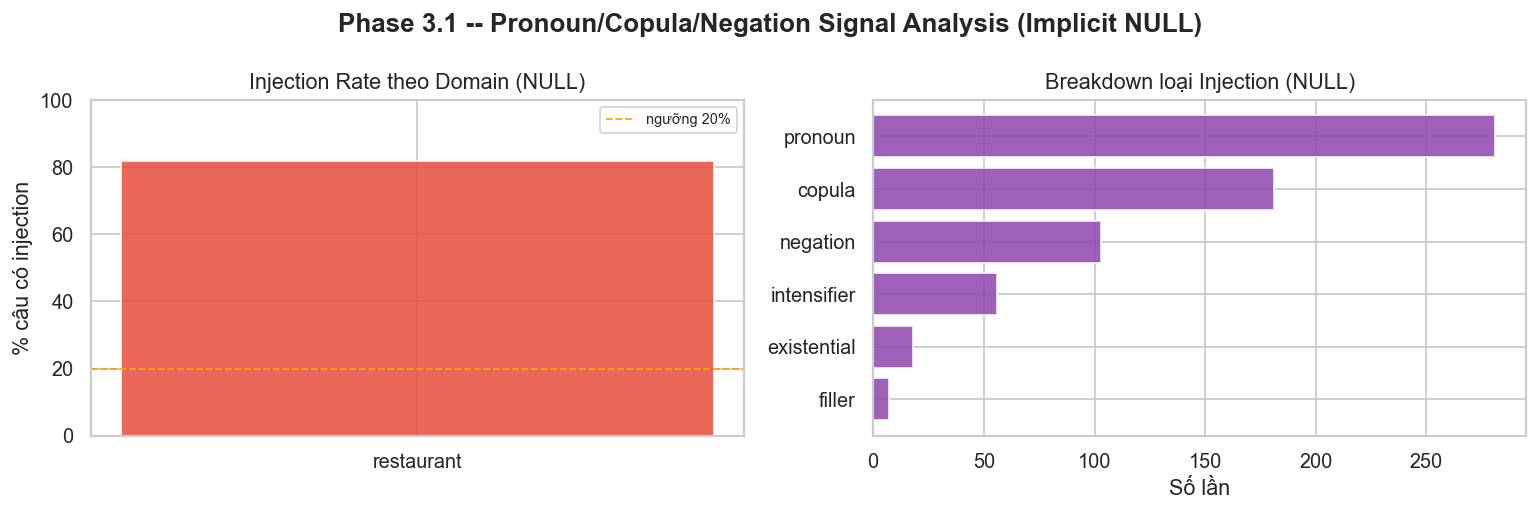

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
if len(implicit_train):
    dom_inj = (
        implicit_train.groupby("domain")["has_injection"]
        .agg(["mean","sum","count"])
        .assign(rate_pct=lambda x: x["mean"]*100)
    )
else:
    dom_inj = pd.DataFrame({"rate_pct": [0]*len(DOMAINS), "sum": [0]*len(DOMAINS), "count": [0]*len(DOMAINS)}, index=DOMAINS)
ax.bar(dom_inj.index, dom_inj["rate_pct"],
       color=["#e74c3c","#3498db"], alpha=0.85)
ax.axhline(20, color="orange", ls="--", lw=1, label="ngưỡng 20%")
ax.set(title="Injection Rate theo Domain (NULL)",
       ylabel="% câu có injection", ylim=(0,100))
ax.legend(fontsize=8)

ax = axes[1]
if len(inj_breakdown) > 0 and inj_breakdown["count"].sum() > 0:
    ax.barh(inj_breakdown["injection_type"][::-1],
            inj_breakdown["count"][::-1], color="#8e44ad", alpha=0.85)
    ax.set(title="Breakdown loại Injection (NULL)", xlabel="Số lần")
else:
    ax.text(0.5,0.5,"Không phát hiện injection",ha="center",va="center",
            transform=ax.transAxes)
    ax.set_title("Injection (không có)")

plt.suptitle("Phase 3.1 -- Pronoun/Copula/Negation Signal Analysis (Implicit NULL)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 — Translationese Artifact Rate

In [25]:
SEVERITY_SCORE = {"HIGH": 3, "MED": 2, "LOW": 1}

DE_ARTIFACT_PATTERNS = {
    "das ist"        : ("copula_bridge", "HIGH", "Literal this/that-is bridge"),
    "es ist"         : ("copula_bridge", "HIGH", "Expletive/copy bridge often seen in literal translation"),
    "es gibt"        : ("existential",   "MED",  "There-is construction, may be overused by MT"),
    "in bezug auf"   : ("topicalizer",   "HIGH", "Regarding/in respect of, formal translationese"),
    "bezüglich"      : ("topicalizer",   "MED",  "Regarding topicalizer"),
    "was betrifft"   : ("topicalizer",   "MED",  "As far as ... is concerned"),
    "im allgemeinen" : ("filler",        "LOW",  "General discourse filler"),
    "alles in allem" : ("filler",        "LOW",  "Overall discourse filler"),
    "ehrlich gesagt" : ("filler",        "LOW",  "Frankly speaking filler"),
    "tatsächlich"    : ("filler",        "LOW",  "Actually/in fact filler"),
    "eigentlich"     : ("filler",        "LOW",  "Actually/really filler"),
    "wird"           : ("passive",       "MED",  "Passive auxiliary"),
    "wurde"          : ("passive",       "MED",  "Past passive auxiliary"),
    "werden"         : ("passive",       "MED",  "Passive auxiliary/infinitive"),
    "von"            : ("passive_agent", "LOW",  "By/from phrase near aspect"),
    "nicht"          : ("negation",      "MED",  "Negation marker"),
    "kein"           : ("negation",      "MED",  "Negative determiner"),
    "keine"          : ("negation",      "MED",  "Negative determiner"),
    "keinen"         : ("negation",      "MED",  "Negative determiner"),
    "sehr"           : ("intensifier",   "LOW",  "Common intensifier"),
    "wirklich"       : ("intensifier",   "LOW",  "Really intensifier"),
    "ziemlich"       : ("intensifier",   "LOW",  "Quite/rather intensifier"),
    "total"          : ("intensifier",   "LOW",  "Overused intensifier"),
    "extrem"         : ("intensifier",   "LOW",  "Strong intensifier"),
}
print(f"Artifact patterns: {len(DE_ARTIFACT_PATTERNS)}")


Artifact patterns: 24


In [26]:
def extract_ngram_window(text, aspect_term, window=6, n=4):
    if not aspect_term or str(aspect_term).upper() == "NULL":
        return [], [], -1
    tokens   = simple_tokenize(text)
    asp_toks = simple_tokenize(aspect_term)
    pos      = -1
    for i in range(len(tokens)-len(asp_toks)+1):
        if tokens[i:i+len(asp_toks)] == asp_toks:
            pos = i
            break
    if pos < 0:
        return [], [], -1
    pre  = tokens[max(0,pos-window):pos]
    post = tokens[pos+len(asp_toks):pos+len(asp_toks)+window]
    def mkng(toks, n):
        out = []
        for k in range(1,n+1):
            # DE phrases are represented with spaces; hyphenated words remain intact.
            out += [" ".join(toks[i:i+k]) for i in range(len(toks)-k+1)]
        return out
    return mkng(pre,n), mkng(post,n), pos


def score_artifacts(ngrams, pattern_dict):
    score, found = 0, []
    for ng in set(ngrams):
        if ng in pattern_dict:
            atype, severity, desc = pattern_dict[ng]
            score += SEVERITY_SCORE[severity]
            found.append((ng, atype, severity))
    return score, found


print("DE n-gram extractor & artifact scorer defined.")


DE n-gram extractor & artifact scorer defined.


In [27]:
explicit_train = train_df[~train_df["is_implicit"]].copy()
print(f"Explicit (non-NULL) train samples: {len(explicit_train):,}")

ngram_data = []
for _, row in explicit_train.iterrows():
    pre, post, pos = extract_ngram_window(row["text"], row["aspect_term"])
    score, found   = score_artifacts(pre+post, DE_ARTIFACT_PATTERNS)
    ngram_data.append({
        "sentence_id"    : row["sentence_id"],
        "domain"         : row["domain"],
        "aspect_term"    : row["aspect_term"],
        "aspect_category": row["aspect_category"],
        "sentiment"      : row["sentiment"],
        "artifact_score" : score,
        "artifact_found" : found,
        "is_artifact"    : (score > 0),
    })

ngram_df      = pd.DataFrame(ngram_data)
ARTIFACT_RATE = ngram_df["is_artifact"].mean() if len(ngram_df) else 0.0
n_artifacts   = int(ngram_df["is_artifact"].sum()) if len(ngram_df) else 0
print(f"Artifact Rate: {n_artifacts}/{len(ngram_df)} = {ARTIFACT_RATE*100:.1f}%")

Explicit (non-NULL) train samples: 4,423
Artifact Rate: 1540/4423 = 34.8%


In [28]:
if len(ngram_df):
    art_by_domain = (
        ngram_df.groupby("domain")["is_artifact"]
        .agg(artifact_count="sum", total="count")
        .assign(artifact_rate=lambda x: (x["artifact_count"]/x["total"]).round(4))
        .reset_index()
    )
else:
    art_by_domain = pd.DataFrame(columns=["domain","artifact_count","total","artifact_rate"])
display(art_by_domain)

all_found = [(ng,at,sv) for fl in ngram_df.get("artifact_found", []) for (ng,at,sv) in fl]
patt_cnt  = Counter(ng for ng,_,_ in all_found)
sev_order = {"HIGH":0,"MED":1,"LOW":2}

art_ref_df = pd.DataFrame([
    {"pattern":ng,"type":at,"severity":sv,"freq":patt_cnt.get(ng,0),"desc":dsc}
    for ng,(at,sv,dsc) in DE_ARTIFACT_PATTERNS.items()
]).sort_values(
    ["severity","freq"],
    key=lambda s: s.map(sev_order) if s.name=="severity" else -s
).reset_index(drop=True)

print("\n=== Artifact Pattern Reference Table ===")
display(art_ref_df)

,domain,artifact_count,total,artifact_rate
0,phone,1152,2883,0.3996
1,restaurant,388,1540,0.2519



=== Artifact Pattern Reference Table ===


,pattern,type,severity,freq,desc
0,es ist,copula_bridge,HIGH,137,Expletive/copy bridge often seen in literal translation
1,das ist,copula_bridge,HIGH,15,Literal this/that-is bridge
2,in bezug auf,topicalizer,HIGH,5,"Regarding/in respect of, formal translationese"
3,nicht,negation,MED,400,Negation marker
4,wird,passive,MED,79,Passive auxiliary
5,keine,negation,MED,66,Negative determiner
6,kein,negation,MED,62,Negative determiner
7,wurde,passive,MED,48,Past passive auxiliary
8,werden,passive,MED,43,Passive auxiliary/infinitive
9,es gibt,existential,MED,20,"There-is construction, may be overused by MT"


In [29]:
def map_dropout(rate, dmap):
    for threshold, dropout in sorted(dmap, reverse=True):
        if rate >= threshold: return dropout
    return dmap[-1][1]


RECOMMENDED_DROPOUT = map_dropout(ARTIFACT_RATE, DROPOUT_MAP)
print(f"Artifact Rate    = {ARTIFACT_RATE*100:.1f}%")
print(f"recommended_dropout = {RECOMMENDED_DROPOUT}")

Artifact Rate    = 34.8%
recommended_dropout = 0.15


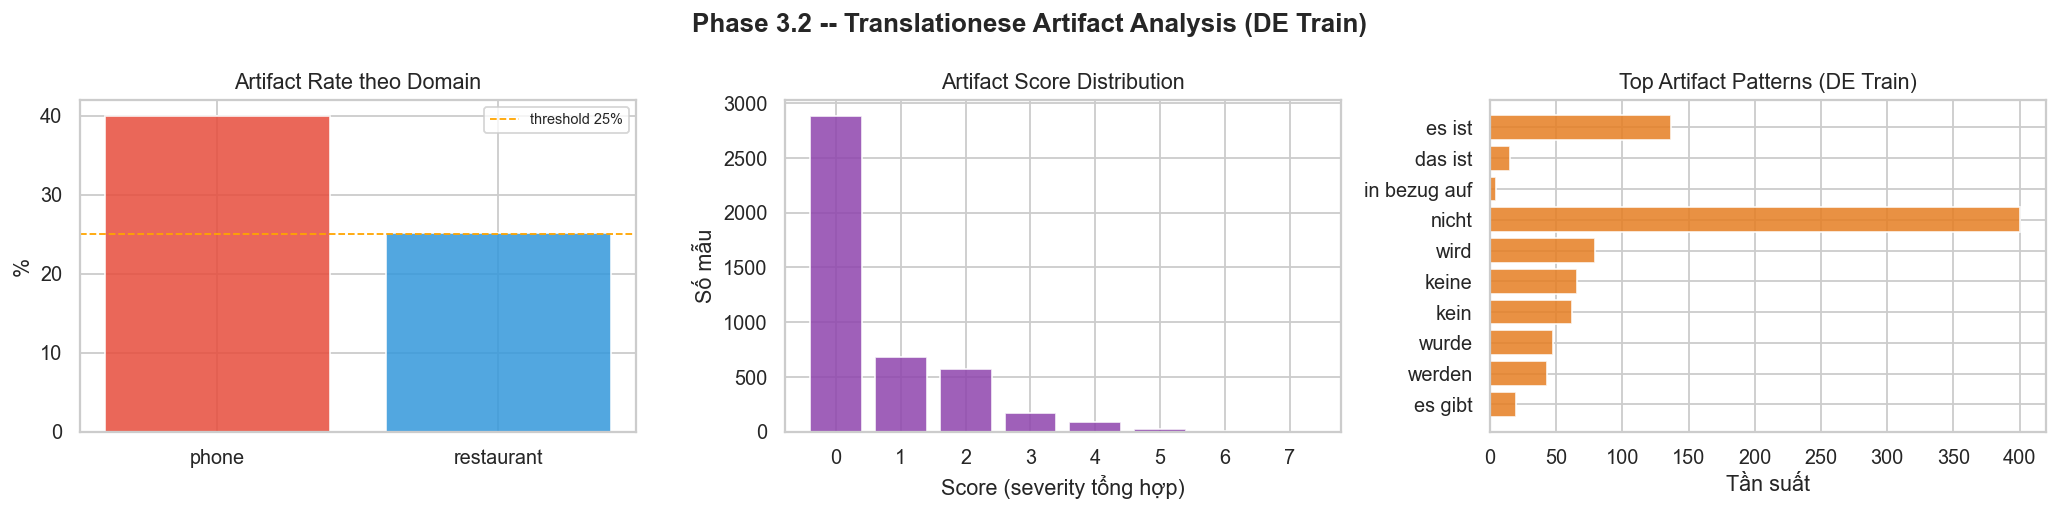

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
if len(art_by_domain):
    ax.bar(art_by_domain["domain"], art_by_domain["artifact_rate"]*100,
           color=["#e74c3c","#3498db"], alpha=0.85)
else:
    ax.bar(DOMAINS, [0]*len(DOMAINS), color=["#e74c3c","#3498db"], alpha=0.85)
ax.axhline(ARTIFACT_HIGH_THRESHOLD*100, color="orange", ls="--", lw=1,
           label=f"threshold {ARTIFACT_HIGH_THRESHOLD*100:.0f}%")
ax.set(title="Artifact Rate theo Domain", ylabel="%")
ax.legend(fontsize=8)

ax = axes[1]
if len(ngram_df):
    sc = ngram_df["artifact_score"].value_counts().sort_index()
    ax.bar(sc.index.astype(str), sc.values, color="#8e44ad", alpha=0.85)
else:
    ax.bar(["0"], [0], color="#8e44ad", alpha=0.85)
ax.set(title="Artifact Score Distribution",
       xlabel="Score (severity tổng hợp)", ylabel="Số mẫu")

ax = axes[2]
top_pat = art_ref_df[art_ref_df["freq"]>0].head(10)
if len(top_pat):
    ax.barh(top_pat["pattern"][::-1], top_pat["freq"][::-1],
            color="#e67e22", alpha=0.85)
    ax.set(title="Top Artifact Patterns (DE Train)", xlabel="Tần suất")
else:
    ax.text(0.5,0.5,"Không có artifact",ha="center",va="center",
            transform=ax.transAxes)
    ax.set_title("Top Artifact Patterns")

plt.suptitle("Phase 3.2 -- Translationese Artifact Analysis (DE Train)", fontweight="bold")
plt.tight_layout()
plt.show()

---
# PHASE 4 — CROSS-SPLIT COVARIATE SHIFT & SPLIT INTEGRITY

> **Mở cả 3 tập Train / Val / Test**

- 4.1 Split Integrity
- 4.2 Category Overlap & Unseen Audit
- 4.3 Sentiment Distribution Shift (TVD)

In [31]:
all_splits_df = df[df["is_valid_sent"]].copy()
print(f"Tổng bản ghi hợp lệ (3 splits): {len(all_splits_df):,}")
print(all_splits_df.groupby(["domain","split"]).size().unstack(fill_value=0))

Tổng bản ghi hợp lệ (3 splits): 8,105
split       dev  test  training
domain                         
phone       710  1217      2883
restaurant  507   799      1989


### 4.1 — Split Integrity

In [32]:
integrity = []
for domain in DOMAINS:
    for split in SPLITS:
        sub   = all_splits_df[(all_splits_df["domain"]==domain) &
                              (all_splits_df["split"]==split)]
        n_sent = sub["sentence_id"].nunique()
        n_trip = len(sub)
        integrity.append({"domain":domain,"split":split,
                          "n_sentences":n_sent,"n_triplets":n_trip,
                          "avg_trip":round(n_trip/n_sent,2) if n_sent else 0})

integrity_df = pd.DataFrame(integrity)
print("=== Split Integrity -- DE ===")
display(integrity_df.pivot_table(
    index="domain",columns="split",
    values=["n_sentences","n_triplets"],fill_value=0
))

print("\nTỷ lệ phân chia (theo số câu):")
for domain in DOMAINS:
    dom   = integrity_df[integrity_df["domain"]==domain].set_index("split")
    total = dom["n_sentences"].sum()
    ratios= (dom["n_sentences"]/total*100).round(1) if total else pd.Series(dtype=float)
    print(f"  {domain}: " + "  ".join(f"{s}={ratios.get(s,0):.1f}%" for s in SPLITS))

=== Split Integrity -- DE ===


n_sentences                 n_triplets                 
split              dev   test training        dev    test training
domain                                                            
phone            256.0  449.0   1073.0      710.0  1217.0   2883.0
restaurant       316.0  544.0   1264.0      507.0   799.0   1989.0


Tỷ lệ phân chia (theo số câu):
  restaurant: training=59.5%  dev=14.9%  test=25.6%
  phone: training=60.3%  dev=14.4%  test=25.3%


### 4.2 — Category Overlap & Unseen Category Audit

In [33]:
def unseen_category_audit(df_all, domain):
    sub  = df_all[df_all["domain"]==domain]
    cats = {s: set(sub.loc[sub["split"]==s,"aspect_category"]) for s in SPLITS}
    tr   = cats["training"]
    return {
        "domain"        : domain,
        "train_cats"    : len(tr),
        "val_cats"      : len(cats["dev"]),
        "test_cats"     : len(cats["test"]),
        "val_unseen_n"  : len(cats["dev"]  - tr),
        "test_unseen_n" : len(cats["test"] - tr),
        "val_unseen"    : sorted(cats["dev"]  - tr),
        "test_unseen"   : sorted(cats["test"] - tr),
    }


overlap_results = [unseen_category_audit(all_splits_df, d) for d in DOMAINS]
overlap_df      = pd.DataFrame(overlap_results)

print("=== Category Overlap Audit ===")
display(overlap_df[["domain","train_cats","val_cats","test_cats",
                     "val_unseen_n","test_unseen_n"]])

for r in overlap_results:
    if r["test_unseen_n"] > 0:
        print(f"\n[WARN] {r['domain'].upper()}: {r['test_unseen_n']} category chưa xuất hiện trong Train:")
        for cat in r["test_unseen"]: print(f"  - {cat}")
    else:
        print(f"\n[OK]   {r['domain'].upper()}: Không có unseen category trong Test.")

=== Category Overlap Audit ===


,domain,train_cats,val_cats,test_cats,val_unseen_n,test_unseen_n
0,restaurant,12,13,12,1,0
1,phone,84,74,76,2,1



[OK]   RESTAURANT: Không có unseen category trong Test.

[WARN] PHONE: 1 category chưa xuất hiện trong Train:
  - product packaging#instruction manual


### 4.3 — Sentiment Distribution Shift (TVD)

In [34]:
LABEL_KEYS = ["positive","negative","neutral"]


def norm_counter(counter, keys):
    total = sum(counter.get(k,0) for k in keys)
    return {k: counter.get(k,0)/total if total else 0.0 for k in keys}


def tvd(p, q, keys):
    return 0.5 * sum(abs(p.get(k,0)-q.get(k,0)) for k in keys)


shift_rows = []
for domain in DOMAINS:
    sub   = all_splits_df[all_splits_df["domain"]==domain]
    train = sub[sub["split"]=="training"]
    val   = sub[sub["split"]=="dev"]
    test  = sub[sub["split"]=="test"]
    p_tr  = norm_counter(Counter(train["sentiment"]),LABEL_KEYS)
    p_val = norm_counter(Counter(val["sentiment"]),  LABEL_KEYS)
    p_te  = norm_counter(Counter(test["sentiment"]), LABEL_KEYS)
    tr_t  = set(train["text"]); val_t = set(val["text"]); te_t = set(test["text"])
    shift_rows.append({
        "domain"            : domain,
        "tvd_train_val"     : round(tvd(p_tr,p_val,LABEL_KEYS),4),
        "tvd_train_test"    : round(tvd(p_tr,p_te, LABEL_KEYS),4),
        "train_pos_pct"     : round(p_tr["positive"]*100,1),
        "train_neg_pct"     : round(p_tr["negative"]*100,1),
        "train_neu_pct"     : round(p_tr["neutral"] *100,1),
        "test_pos_pct"      : round(p_te["positive"]*100,1),
        "test_neg_pct"      : round(p_te["negative"]*100,1),
        "test_neu_pct"      : round(p_te["neutral"] *100,1),
        "train_val_overlap" : len(tr_t & val_t),
        "train_test_overlap": len(tr_t & te_t),
    })

shift_df = pd.DataFrame(shift_rows)
print("=== Covariate Shift Summary -- DE ===")
display(shift_df)

=== Covariate Shift Summary -- DE ===


,domain,tvd_train_val,tvd_train_test,train_pos_pct,train_neg_pct,train_neu_pct,test_pos_pct,test_neg_pct,test_neu_pct,train_val_overlap,train_test_overlap
0,restaurant,0.0157,0.0603,68.8,28.1,3.1,73.0,22.0,5.0,3,4
1,phone,0.0174,0.0108,73.5,22.4,4.0,74.6,21.6,3.8,0,0


In [35]:
for _, row in shift_df.iterrows():
    dom = row["domain"]
    if row["train_test_overlap"] > 0:
        print(f"[WARN] {dom}: {row['train_test_overlap']} câu trùng Train<->Test (data leakage!)")
    else:
        print(f"[OK]   {dom}: Không có text overlap Train<->Test.")
    tvd_v = row["tvd_train_test"]
    marker = "WARN" if tvd_v > 0.05 else "OK"
    print(f"  [{marker}] TVD(train,test) = {tvd_v:.4f}", end="")
    print(" — cần xem lại" if tvd_v > 0.05 else " — ổn định")

[WARN] restaurant: 4 câu trùng Train<->Test (data leakage!)
  [WARN] TVD(train,test) = 0.0603 — cần xem lại
[OK]   phone: Không có text overlap Train<->Test.
  [OK] TVD(train,test) = 0.0108 — ổn định


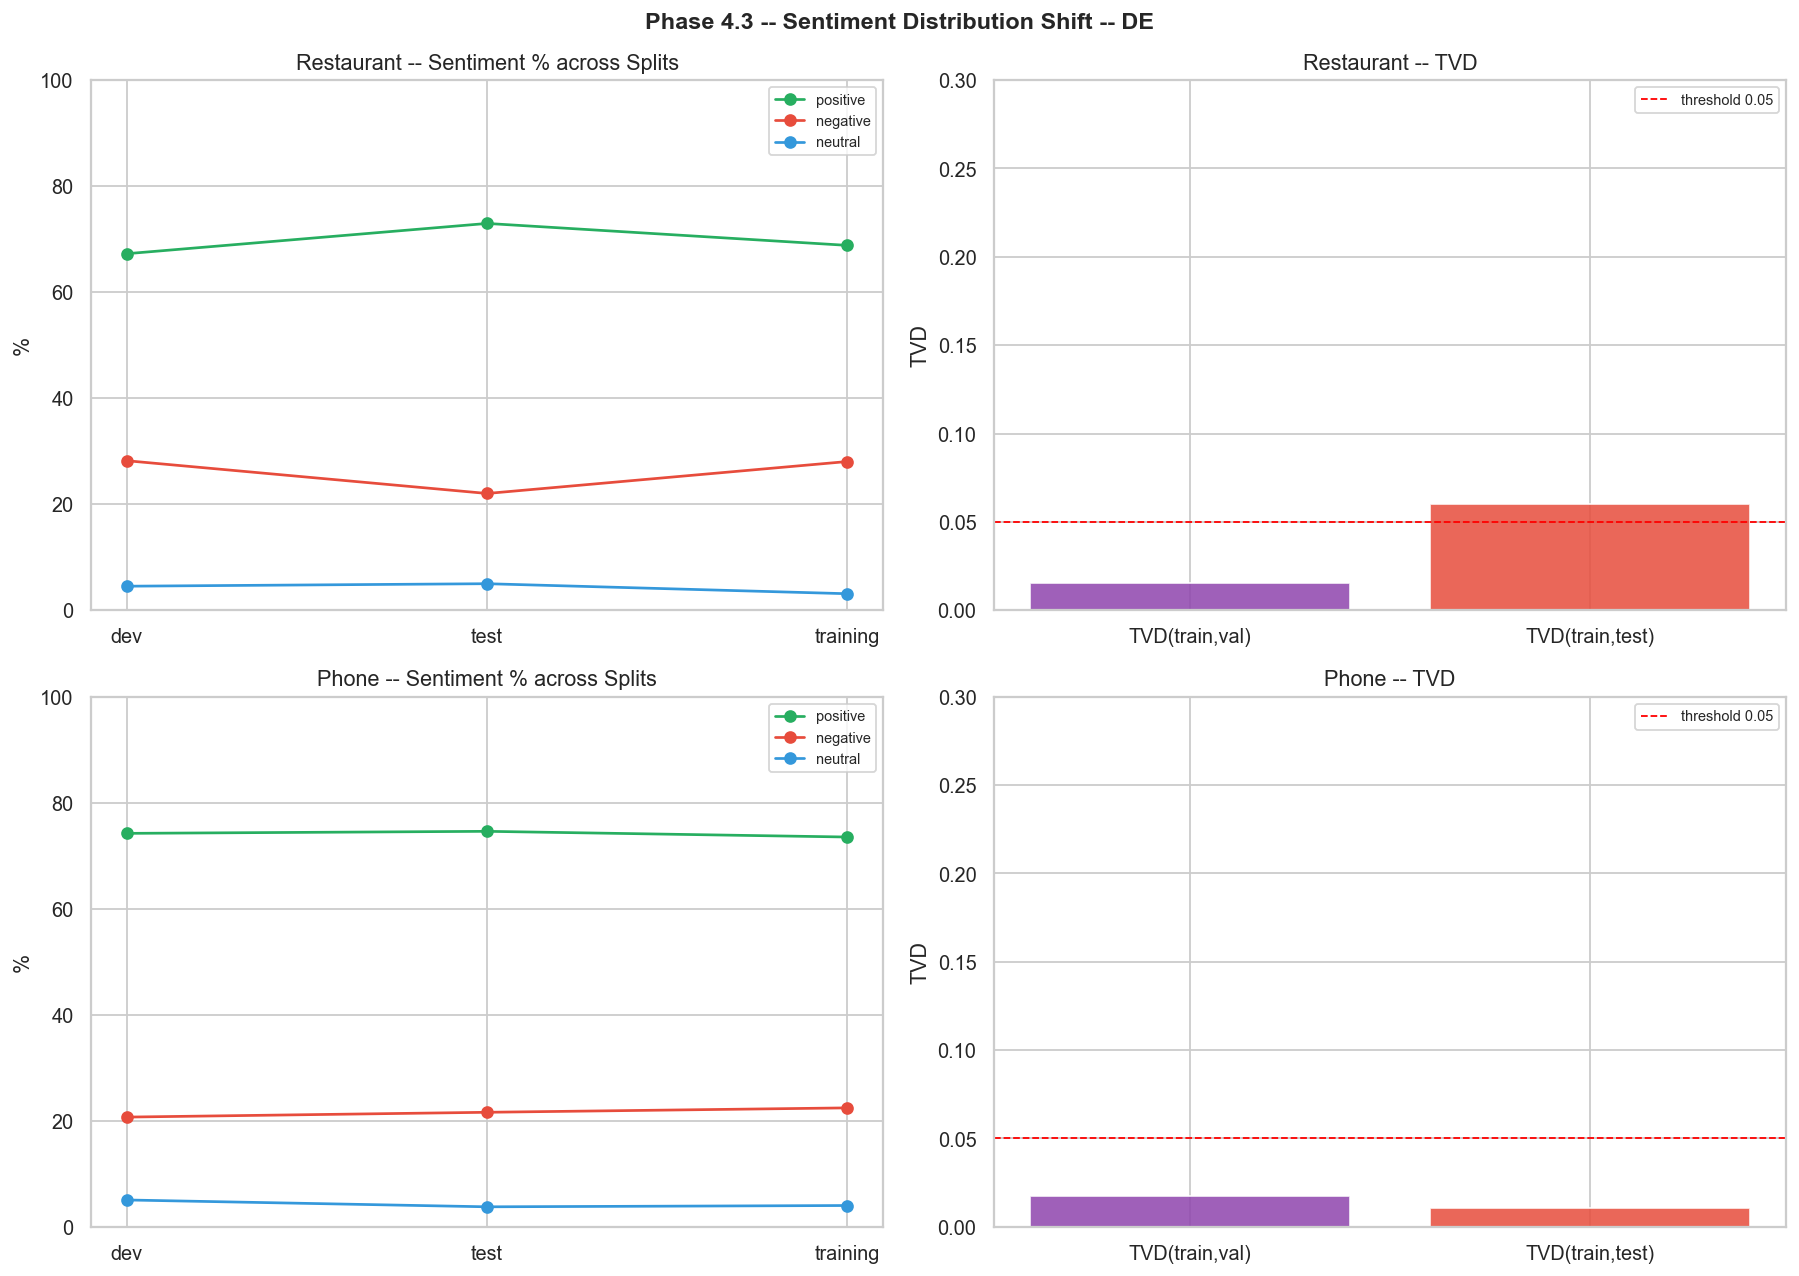

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_i, domain in enumerate(DOMAINS):
    sub = all_splits_df[all_splits_df["domain"]==domain]

    ax = axes[row_i][0]
    spl = (sub.groupby(["split","sentiment"]).size().rename("n").reset_index())
    if len(spl):
        spl["pct"] = spl.groupby("split")["n"].transform(lambda x: x/x.sum()*100)
    else:
        spl["pct"] = []
    for lbl in LABEL_KEYS:
        s = spl[spl["sentiment"]==lbl]
        ax.plot(s["split"], s["pct"], marker="o", label=lbl, color=C[lbl])
    ax.set(title=f"{domain.capitalize()} -- Sentiment % across Splits",
           ylabel="%", ylim=(0,100))
    ax.legend(fontsize=8)

    ax = axes[row_i][1]
    dom_row = shift_df[shift_df["domain"]==domain].iloc[0]
    ax.bar(["TVD(train,val)","TVD(train,test)"],
           [dom_row["tvd_train_val"],dom_row["tvd_train_test"]],
           color=["#8e44ad","#e74c3c"], alpha=0.85)
    ax.axhline(0.05, color="red", ls="--", lw=1, label="threshold 0.05")
    ax.set(title=f"{domain.capitalize()} -- TVD", ylabel="TVD", ylim=(0,0.3))
    ax.legend(fontsize=8)

plt.suptitle("Phase 4.3 -- Sentiment Distribution Shift -- DE",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

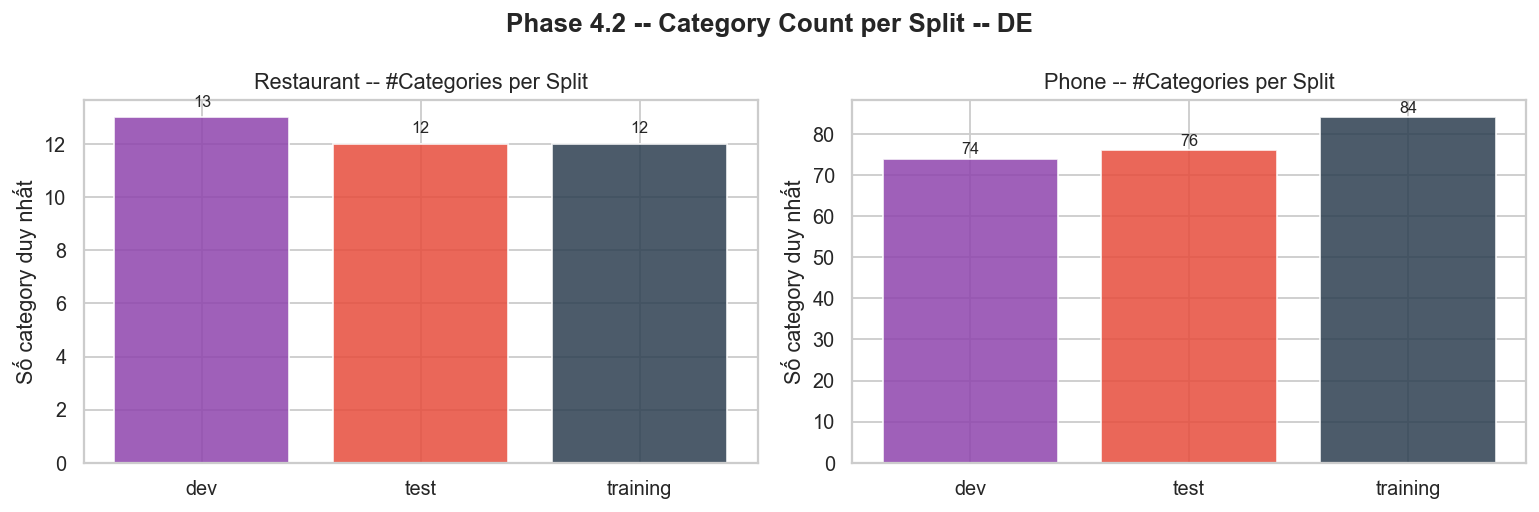

In [37]:
cat_per_split = (
    all_splits_df.groupby(["domain","split"])["aspect_category"]
    .nunique().rename("n_cats").reset_index()
)
split_colors = {"training":C["train"],"dev":C["val"],"test":C["test"]}
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, domain in zip(axes, DOMAINS):
    sub  = cat_per_split[cat_per_split["domain"]==domain]
    bars = ax.bar(sub["split"],sub["n_cats"],
                  color=[split_colors.get(s,"gray") for s in sub["split"]], alpha=0.85)
    for bar, row in zip(bars, sub.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(row.n_cats), ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{domain.capitalize()} -- #Categories per Split",
           ylabel="Số category duy nhất")
plt.suptitle("Phase 4.2 -- Category Count per Split -- DE", fontweight="bold")
plt.tight_layout()
plt.show()

---
# PHASE 5 — MODEL CONFIGURATION SUMMARY

Đóng gói toàn bộ phát hiện định lượng từ Phase 2, 3, 4 thành **Config Dictionary** dùng cho pipeline huấn luyện.

In [38]:
high_tvd_domains   = [r["domain"] for _,r in shift_df.iterrows() if r["tvd_train_test"]>0.05]
leakage_domains    = [r["domain"] for _,r in shift_df.iterrows() if r["train_test_overlap"]>0]
unseen_cat_domains = [r["domain"] for r in overlap_results if r["test_unseen_n"]>0]

model_signals = {
    "language"                    : TARGET_LANG,
    "tokenizer"                   : TOKENIZER_NAME,
    # Phase 2.1
    "recommended_max_length"      : RECOMMENDED_MAX_LENGTH,
    "token_p90_restaurant"        : int(len_by_domain.loc[len_by_domain["domain"]=="restaurant","p90"].iloc[0]),
    "token_p95_restaurant"        : int(len_by_domain.loc[len_by_domain["domain"]=="restaurant","p95"].iloc[0]),
    "token_p90_phone"             : int(len_by_domain.loc[len_by_domain["domain"]=="phone","p90"].iloc[0]),
    "token_p95_phone"             : int(len_by_domain.loc[len_by_domain["domain"]=="phone","p95"].iloc[0]),
    # Phase 2.2
    "requires_class_weight"       : REQUIRES_CLASS_WEIGHT,
    "class_weights"               : {
        row["domain"]: {
            "positive": float(cw.loc[cw["domain"]==row["domain"],"w_positive"].iloc[0]),
            "negative": float(cw.loc[cw["domain"]==row["domain"],"w_negative"].iloc[0]),
            "neutral" : float(cw.loc[cw["domain"]==row["domain"],"w_neutral"].iloc[0]),
        }
        for _,row in label_by_domain.iterrows()
    },
    # Phase 2.3
    "n_categories_restaurant"     : int(len(cat_rest)),
    "n_rare_categories_restaurant": int(cat_rest["is_rare"].sum()),
    "n_categories_phone"          : int(len(cat_phone)),
    "n_rare_categories_phone"     : int(cat_phone["is_rare"].sum()),
    # Phase 3.1
    "implicit_injection_rate"     : round(inj_rate/100, 4),
    "attention_mask_strategy"     : ATTENTION_MASK_STRATEGY,
    # Phase 3.2
    "artifact_rate"               : round(ARTIFACT_RATE, 4),
    "recommended_dropout"         : RECOMMENDED_DROPOUT,
    # Phase 4
    "high_tvd_domains"            : high_tvd_domains,
    "leakage_domains"             : leakage_domains,
    "unseen_category_domains"     : unseen_cat_domains,
    "tvd_train_test"              : {
        row["domain"]: float(row["tvd_train_test"])
        for _,row in shift_df.iterrows()
    },
}

print(json.dumps(model_signals, indent=4, ensure_ascii=False))

{
    "language": "de",
    "tokenizer": "xlm-roberta-base",
    "recommended_max_length": 192,
    "token_p90_restaurant": 48,
    "token_p95_restaurant": 57,
    "token_p90_phone": 115,
    "token_p95_phone": 168,
    "requires_class_weight": true,
    "class_weights": {
        "phone": {
            "positive": 0.4533,
            "negative": 1.4853,
            "neutral": 8.2845
        },
        "restaurant": {
            "positive": 0.4843,
            "negative": 1.1882,
            "neutral": 10.6935
        }
    },
    "n_categories_restaurant": 12,
    "n_rare_categories_restaurant": 1,
    "n_categories_phone": 84,
    "n_rare_categories_phone": 43,
    "implicit_injection_rate": 0.8196,
    "attention_mask_strategy": "dynamic",
    "artifact_rate": 0.3482,
    "recommended_dropout": 0.15,
    "high_tvd_domains": [
        "restaurant"
    ],
    "leakage_domains": [
        "restaurant"
    ],
    "unseen_category_domains": [
        "phone"
    ],
    "tvd_train_test":

In [39]:
config_path = PROCESSED_DIR / "model_signals_de.json"
with open(config_path,"w",encoding="utf-8") as f:
    json.dump(model_signals, f, indent=4, ensure_ascii=False)
print(f"Model signals saved -> {config_path}")

Model signals saved -> D:\Project_NLP\Cross-lingual-ABSA-EN-VI-Transfer 2\Cross-lingual-ABSA-EN-VI-Transfer\data\processed\de\model_signals_de.json


In [40]:
print("="*64)
print(f"  M-ABSA EDA SUMMARY -- Language: {TARGET_LANG.upper()}")
print("="*64)
print("\n[ PHASE 2 -- Macro EDA ]")
print(f"  recommended_max_length : {model_signals['recommended_max_length']}")
print(f"  requires_class_weight  : {model_signals['requires_class_weight']}")
print(f"  n_categories rest={model_signals['n_categories_restaurant']}  "
      f"phone={model_signals['n_categories_phone']}")
print(f"  rare_categories  rest={model_signals['n_rare_categories_restaurant']}  "
      f"phone={model_signals['n_rare_categories_phone']}")
print("\n[ PHASE 3 -- Micro-Linguistic ]")
print(f"  injection_rate          : {model_signals['implicit_injection_rate']*100:.1f}%")
print(f"  attention_mask_strategy : {model_signals['attention_mask_strategy']}")
print(f"  artifact_rate           : {model_signals['artifact_rate']*100:.1f}%")
print(f"  recommended_dropout     : {model_signals['recommended_dropout']}")
print("\n[ PHASE 4 -- Covariate Shift ]")
for dom, tvd_v in model_signals["tvd_train_test"].items():
    flag = "[WARN]" if tvd_v > 0.05 else "[OK]  "
    print(f"  {flag} TVD(train,test) {dom:<12}: {tvd_v:.4f}")
if model_signals["leakage_domains"]:
    print(f"  [WARN] Leakage: {model_signals['leakage_domains']}")
if model_signals["unseen_category_domains"]:
    print(f"  [WARN] Unseen cats in Test: {model_signals['unseen_category_domains']}")
print("\n" + "="*64)

  M-ABSA EDA SUMMARY -- Language: DE

[ PHASE 2 -- Macro EDA ]
  recommended_max_length : 192
  requires_class_weight  : True
  n_categories rest=12  phone=84
  rare_categories  rest=1  phone=43

[ PHASE 3 -- Micro-Linguistic ]
  injection_rate          : 82.0%
  attention_mask_strategy : dynamic
  artifact_rate           : 34.8%
  recommended_dropout     : 0.15

[ PHASE 4 -- Covariate Shift ]
  [WARN] TVD(train,test) restaurant  : 0.0603
  [OK]   TVD(train,test) phone       : 0.0108
  [WARN] Leakage: ['restaurant']
  [WARN] Unseen cats in Test: ['phone']

